First 5 Rows:


,Month of Order Date,Category,Target
0,Apr-18,Furniture,10400.0
1,May-18,Furniture,10500.0
2,Jun-18,Furniture,10600.0
3,Jul-18,Furniture,10800.0
4,Aug-18,Furniture,10900.0



Dataset Shape: (36, 3)

Columns:
['Month of Order Date', 'Category', 'Target']

Transaction Basket:


Category,Clothing,Electronics,Furniture
Month of Order Date,,,
2018-04-01,True,True,True
2018-05-01,True,True,True
2018-06-01,True,True,True
2018-07-01,True,True,True
2018-08-01,True,True,True
2018-09-01,True,True,True
2018-10-01,True,True,True
2018-11-01,True,True,True
2018-12-01,True,True,True



Frequent Itemsets:


,support,itemsets
0,1.0,frozenset({Clothing})
1,1.0,frozenset({Electronics})
2,1.0,frozenset({Furniture})
3,1.0,"frozenset({Electronics, Clothing})"
4,1.0,"frozenset({Furniture, Clothing})"
5,1.0,"frozenset({Electronics, Furniture})"
6,1.0,"frozenset({Electronics, Furniture, Clothing})"



Association Rules:


c:\Users\Arvind\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:184: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,support,confidence,lift
0,frozenset({Electronics}),frozenset({Clothing}),1.0,1.0,1.0
1,frozenset({Clothing}),frozenset({Electronics}),1.0,1.0,1.0
2,frozenset({Furniture}),frozenset({Clothing}),1.0,1.0,1.0
3,frozenset({Clothing}),frozenset({Furniture}),1.0,1.0,1.0
4,frozenset({Electronics}),frozenset({Furniture}),1.0,1.0,1.0
5,frozenset({Furniture}),frozenset({Electronics}),1.0,1.0,1.0
6,"frozenset({Electronics, Furniture})",frozenset({Clothing}),1.0,1.0,1.0
7,"frozenset({Electronics, Clothing})",frozenset({Furniture}),1.0,1.0,1.0
8,"frozenset({Furniture, Clothing})",frozenset({Electronics}),1.0,1.0,1.0
9,frozenset({Electronics}),"frozenset({Furniture, Clothing})",1.0,1.0,1.0


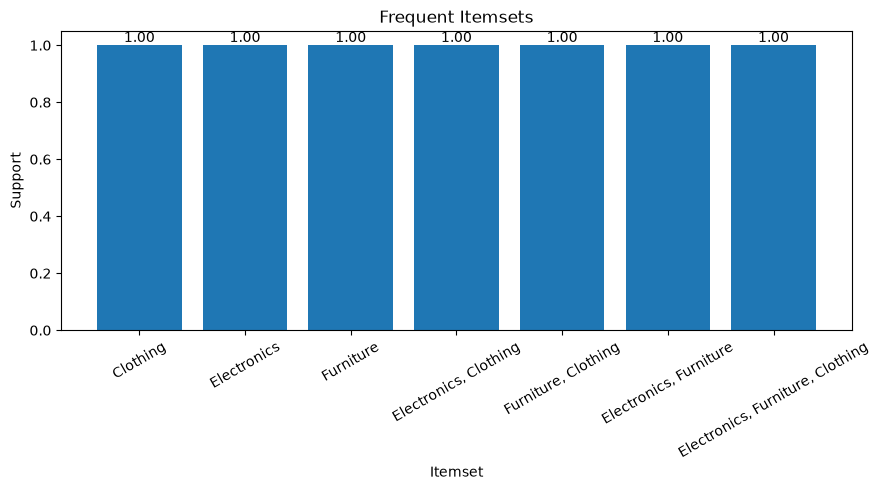

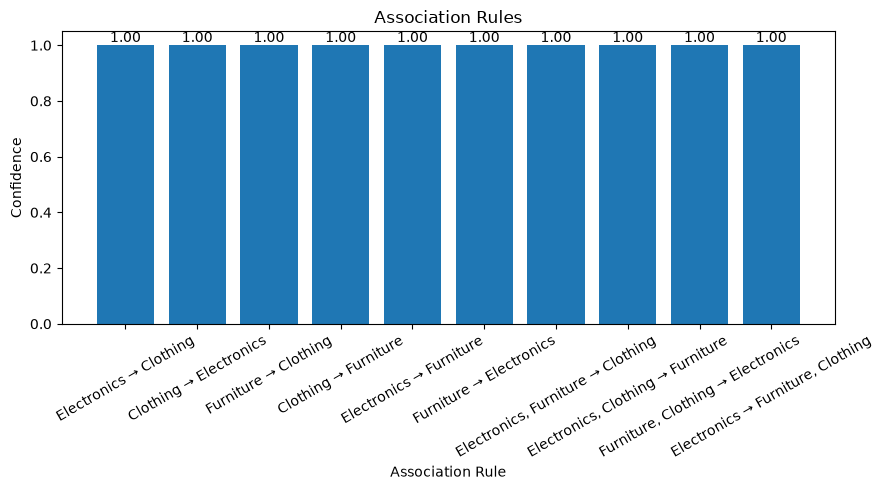

In [1]:
# PRACTICAL: ASSOCIATION RULE MINING
# Dataset: Sales target(1).csv

import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules

df = pd.read_csv("C:/Users/Arvind/Downloads/Sales target.csv")

print("First 5 Rows:")
display(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df["Month of Order Date"] = pd.to_datetime(
    df["Month of Order Date"],
    format="%b-%y"
)

data = df[
    ["Month of Order Date", "Category"]
].dropna()

basket = pd.crosstab(
    data["Month of Order Date"],
    data["Category"]
)

basket = basket.astype(bool)

print("\nTransaction Basket:")
display(basket)

frequent_itemsets = apriori(
    basket,
    min_support=0.2,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    "support",
    ascending=False
)

print("\nFrequent Itemsets:")
display(frequent_itemsets)

if not frequent_itemsets.empty:

    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=0.5
    )

    if not rules.empty:

        rules = rules.sort_values(
            ["confidence", "lift"],
            ascending=False
        )

        print("\nAssociation Rules:")

        display(
            rules[
                [
                    "antecedents",
                    "consequents",
                    "support",
                    "confidence",
                    "lift"
                ]
            ]
        )

    else:
        rules = pd.DataFrame()
        print("\nNo association rules found.")

else:

    rules = pd.DataFrame()
    print("\nNo frequent itemsets found.")

if not frequent_itemsets.empty:

    top = frequent_itemsets.head(10).copy()

    top["Itemset"] = top["itemsets"].apply(
        lambda x: ", ".join(x)
    )

    plt.figure(figsize=(9, 5))

    bars = plt.bar(
        top["Itemset"],
        top["support"]
    )

    plt.xlabel("Itemset")
    plt.ylabel("Support")
    plt.title("Frequent Itemsets")

    plt.xticks(rotation=30)

    for bar, value in zip(
        bars,
        top["support"]
    ):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.2f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

if not rules.empty:

    top_rules = rules.head(10).copy()

    top_rules["Rule"] = (
        top_rules["antecedents"].apply(
            lambda x: ", ".join(x)
        )
        + " → "
        + top_rules["consequents"].apply(
            lambda x: ", ".join(x)
        )
    )

    plt.figure(figsize=(9, 5))

    bars = plt.bar(
        top_rules["Rule"],
        top_rules["confidence"]
    )

    plt.xlabel("Association Rule")
    plt.ylabel("Confidence")
    plt.title("Association Rules")

    plt.xticks(rotation=30)

    for bar, value in zip(
        bars,
        top_rules["confidence"]
    ):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.2f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()